In [1]:
import pandas as pd

train_df = pd.read_csv("/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/train_annotations.csv")
val_df = pd.read_csv("/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/val_annotations.csv")
test_df = pd.read_csv("/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/test_annotations.csv")

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

train_df.head()

Train: 39241
Val: 8386
Test: 8453


,image,category,bbox,segmentation
0,161364.jpg,trousers,"[252, 323, 522, 639]","[[432, 324, 339, 353, 250, 393, 290, 532, 346,..."
1,161364.jpg,short sleeve top,"[30, 1, 466, 481]","[[183, 5, 175, 19, 157, 35, 125, 48, 92, 51, 8..."
2,117178.jpg,trousers,"[159, 423, 337, 701]","[[328, 432, 249, 432, 162, 430, 164, 540, 164,..."
3,131919.jpg,trousers,"[158, 381, 366, 650]","[[346, 450, 263, 438, 227, 388, 203, 451, 186,..."
4,131919.jpg,short sleeve top,"[212, 140, 481, 492]","[[429, 214, 407, 230, 378, 229, 354, 210, 353,..."


In [2]:
import pandas as pd

train_df = pd.read_csv("/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/train_annotations.csv")
val_df = pd.read_csv("/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/val_annotations.csv")
test_df = pd.read_csv("/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/test_annotations.csv")

# group labels per image
train_group = train_df.groupby("image")["category"].apply(list).reset_index()
val_group = val_df.groupby("image")["category"].apply(list).reset_index()
test_group = test_df.groupby("image")["category"].apply(list).reset_index()

train_group.head()

,image,category
0,000014.jpg,"[skirt, long sleeve top]"
1,000015.jpg,[long sleeve top]
2,000018.jpg,"[trousers, long sleeve top]"
3,000026.jpg,"[skirt, short sleeve top]"
4,000027.jpg,"[skirt, short sleeve top]"


In [3]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

train_labels = mlb.fit_transform(train_group["category"])
val_labels = mlb.transform(val_group["category"])
test_labels = mlb.transform(test_group["category"])

print(mlb.classes_)

['long sleeve top' 'short sleeve top' 'shorts' 'skirt' 'trousers']


In [4]:
import torch 
labels_matrix = train_labels   # shape [N, C]

pos_counts = labels_matrix.sum(axis=0)
neg_counts = labels_matrix.shape[0] - pos_counts

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pos_weight = torch.tensor(
    neg_counts / (pos_counts + 1e-6),
    dtype=torch.float
).to(device)
print(mlb.classes_)
print("Correct pos_weight:", pos_weight)

['long sleeve top' 'short sleeve top' 'shorts' 'skirt' 'trousers']
Correct pos_weight: tensor([3.0496, 1.0334, 2.9657, 3.6053, 1.6412], device='cuda:0')


In [5]:
from torchvision import transforms

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Added Gaussian Blur
    transforms.ToTensor(),
    normalize
])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
])

In [6]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import os

class FashionDataset(Dataset):

    def __init__(self, df, labels, img_dir, transform=None):
        self.df = df
        self.labels = labels
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_name = self.df.iloc[idx]["image"]
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label = torch.tensor(self.labels[idx]).float()

        if self.transform:
            image = self.transform(image)

        return image, label

In [7]:
img_dir = "/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/sample_35k/sample_35k/images"

train_dataset = FashionDataset(train_group, train_labels, img_dir, train_tf)
val_dataset = FashionDataset(val_group, val_labels, img_dir, val_tf)
test_dataset = FashionDataset(test_group, test_labels, img_dir, val_tf)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 24500
Val: 5250
Test: 5250


In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32, 5])


# EfficientNetB0

In [9]:
import torchvision.models as models
import torch.nn as nn
import torch

num_classes = len(mlb.classes_)

model = models.efficientnet_b0(weights=None)

# freeze backbone
for param in model.parameters():
    param.requires_grad = True

# replace final layer
model.classifier = nn.Sequential(
    nn.Linear(model.classifier[1].in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [10]:
import torch.optim as optim
from torch.optim import lr_scheduler
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

In [11]:
num_epochs =35
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            val_loss += criterion(model(images), labels).item()
    
    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_effnet.pth')
        print("✔ Best model saved")

Epoch [1/35] | Train Loss: 0.9435 | Val Loss: 0.9196
✔ Best model saved
Epoch [2/35] | Train Loss: 0.9046 | Val Loss: 0.8562
✔ Best model saved
Epoch [3/35] | Train Loss: 0.8520 | Val Loss: 0.8157
✔ Best model saved
Epoch [4/35] | Train Loss: 0.8231 | Val Loss: 0.7928
✔ Best model saved
Epoch [5/35] | Train Loss: 0.7940 | Val Loss: 0.7733
✔ Best model saved
Epoch [6/35] | Train Loss: 0.7731 | Val Loss: 0.7476
✔ Best model saved
Epoch [7/35] | Train Loss: 0.7510 | Val Loss: 0.7382
✔ Best model saved
Epoch [8/35] | Train Loss: 0.7307 | Val Loss: 0.7186
✔ Best model saved
Epoch [9/35] | Train Loss: 0.7109 | Val Loss: 0.7115
✔ Best model saved
Epoch [10/35] | Train Loss: 0.6900 | Val Loss: 0.7005
✔ Best model saved
Epoch [11/35] | Train Loss: 0.6705 | Val Loss: 0.6899
✔ Best model saved
Epoch [12/35] | Train Loss: 0.6494 | Val Loss: 0.6949
Epoch [13/35] | Train Loss: 0.6296 | Val Loss: 0.6944
Epoch [14/35] | Train Loss: 0.6133 | Val Loss: 0.6763
✔ Best model saved
Epoch [15/35] | Train Los

In [12]:
from sklearn.metrics import classification_report
import torch
import numpy as np
from sklearn.metrics import f1_score

model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.cpu().numpy())

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)
thresholds = []

for i in range(all_probs.shape[1]):
    best_t = 0.5
    best_f1 = 0

    for t in np.arange(0.1, 0.9, 0.05):
        preds = (all_probs[:, i] > t).astype(int)
        f1 = f1_score(all_labels[:, i], preds,zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    thresholds.append(best_t)
all_preds = np.zeros_like(all_probs)
for i in range(len(thresholds)):
    all_preds[:, i] = (all_probs[:, i] > thresholds[i]).astype(int)

In [13]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=mlb.classes_
))

                  precision    recall  f1-score   support

 long sleeve top       0.48      0.69      0.57      1312
short sleeve top       0.59      0.92      0.72      2566
          shorts       0.70      0.69      0.69      1329
           skirt       0.44      0.65      0.52      1104
        trousers       0.81      0.82      0.82      1992

       micro avg       0.60      0.79      0.68      8303
       macro avg       0.60      0.76      0.66      8303
    weighted avg       0.62      0.79      0.69      8303
     samples avg       0.63      0.79      0.68      8303



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(all_labels, all_preds, average='macro')
micro_f1 = f1_score(all_labels, all_preds, average='micro')

print("Macro F1:", macro_f1)
print("Micro F1:", micro_f1)

Macro F1: 0.6649507526537035
Micro F1: 0.6842545188590534


In [15]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(all_labels, all_preds, average=None)

for i, cls in enumerate(mlb.classes_):
    print(cls, "AUC:", roc_auc[i])

long sleeve top AUC: 0.7224967174125778
short sleeve top AUC: 0.659062740665797
shorts AUC: 0.7937338047199688
skirt AUC: 0.7143488223326833
trousers AUC: 0.852700396429179


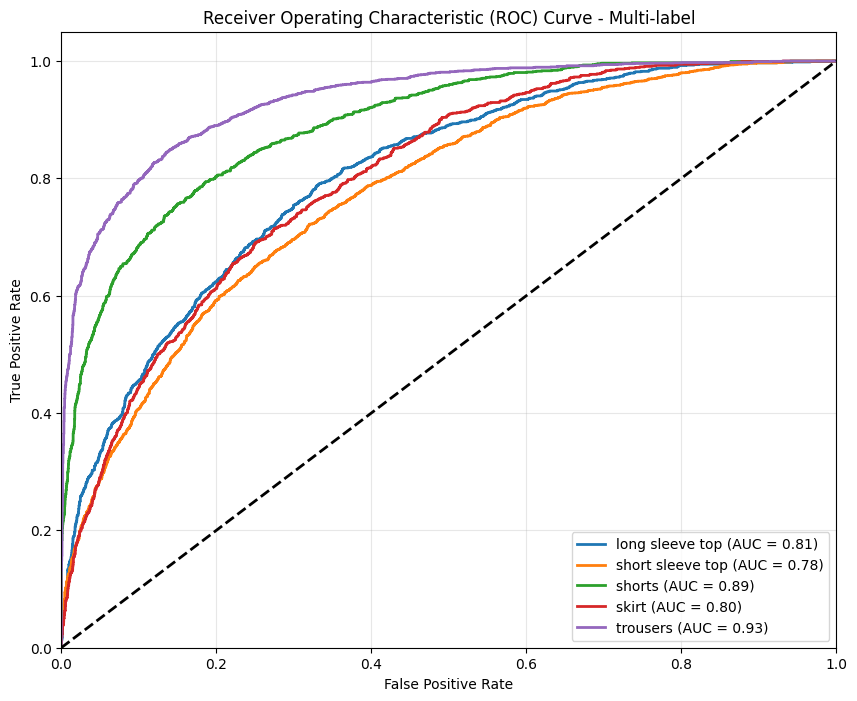

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_multilabel_roc(all_labels, all_probs, class_names):
    plt.figure(figsize=(10, 8))
    
    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve - Multi-label')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# Generate the plot using labels and probabilities from the latest model evaluation
plot_multilabel_roc(all_labels, all_probs, mlb.classes_)